## Gamma Scalping — Volatility Model Playground

This notebook is a playground for exploring different approaches to **volatility estimation and forecasting**.  
The goal is to build intuition for how various models behave on historical data,  
and to compare their forecasts against realized volatility.

In [20]:
import sys, os
sys.path.append(os.path.abspath(".."))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from models.volatility.target import log_returns, realized_future_vol
from models.volatility.estimator import close_to_close_vol, parkinson_vol
from models.volatility.forecast import naive_forecast, garch_forecast

import seaborn as sns

from pathlib import Path
from datetime import datetime

# Set styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
pd.set_option('display.max_columns', None)

Given the parsed spot price data set (in this case here given hourly), we compute the hourly and daily log-returns.

In [21]:
spot = Path('../data/parsed/spot/BTCUSDT_1h.feather')

df = pd.read_feather(spot)

df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

# Hourly log returns
r_hourly = log_returns(df, "hourly")
print("\n--- Hourly log returns ---")
print(r_hourly.head())

# Daily log returns
r_daily = log_returns(df, "daily")
print("\n--- Daily log returns ---")
print(r_daily.head())


--- Hourly log returns ---
datetime
2019-03-30 00:00:00+00:00         NaN
2019-03-30 01:00:00+00:00   -0.002372
2019-03-30 02:00:00+00:00   -0.000430
2019-03-30 03:00:00+00:00   -0.006429
2019-03-30 04:00:00+00:00   -0.002443
Name: logret_hourly, dtype: float64

--- Daily log returns ---
datetime
2019-03-30 00:00:00+00:00         NaN
2019-03-31 00:00:00+00:00   -0.000736
2019-04-01 00:00:00+00:00    0.009847
2019-04-02 00:00:00+00:00    0.158684
2019-04-03 00:00:00+00:00    0.015386
Freq: D, Name: logret_daily, dtype: float64


### Constructing Realized Volatility Targets

We consider the **forward-looking realized volatility** as the benchmark target for forecast evaluation. For each timestamp $t$, the function looks ahead to the next $h$ periods $(t+1, \dots, t+h)$, computes their realized variance, annualizes it, and aligns the result back to time $t$:

$$
RV_{t,h} \;=\; 
\sqrt{ \frac{ann}{h} \sum_{i=1}^{h} r_{t+i}^{2} } \times 100
$$

where  

- $r_{t+i}$ = log-return at step $t+i$  
- $h$ = forecast horizon (hours or days)  
- $ann$ = annualization factor (8760 for hourly, 365 for daily)

---

**Usage examples:**

```python
# Hourly horizon: next 2 hours volatility (annualized, %)
y_2h = realized_future_vol(df, h=2, freq="hourly")

# Hourly horizon: next 24 hours volatility (annualized, %)
y_24h = realized_future_vol(df, h=24, freq="hourly")

# Daily horizon: next 7 days volatility (annualized, %)
y_7d = realized_future_vol(df, h=7, freq="daily")

# Daily horizon: next 30 days volatility (annualized, %)
y_30d = realized_future_vol(df, h=30, freq="daily")



In [22]:
y_2h = realized_future_vol(df, h=2, freq="hourly")
print(y_2h.head())

y_24h = realized_future_vol(df, h=24, freq="hourly")
print(y_24h.head())

y_7d = realized_future_vol(df, h=7, freq="daily")
print(y_7d.head())

y_30d = realized_future_vol(df, h=30, freq="daily")
print(y_30d.head())

datetime
2019-03-30 00:00:00+00:00    15.956558
2019-03-30 01:00:00+00:00    42.640374
2019-03-30 02:00:00+00:00    45.515144
2019-03-30 03:00:00+00:00    36.312275
2019-03-30 04:00:00+00:00    33.407712
Name: rv_vol_future_2h_pct, dtype: float64
datetime
2019-03-30 00:00:00+00:00    22.305981
2019-03-30 01:00:00+00:00    21.842532
2019-03-30 02:00:00+00:00    22.419329
2019-03-30 03:00:00+00:00    19.494366
2019-03-30 04:00:00+00:00    18.951532
Name: rv_vol_future_24h_pct, dtype: float64
datetime
2019-03-30 00:00:00+00:00    116.621635
2019-03-31 00:00:00+00:00    117.981616
2019-04-01 00:00:00+00:00    118.129591
2019-04-02 00:00:00+00:00     31.156059
2019-04-03 00:00:00+00:00     36.399156
Freq: D, Name: rv_vol_future_7d_pct, dtype: float64
datetime
2019-03-30 00:00:00+00:00    66.300587
2019-03-31 00:00:00+00:00    66.524698
2019-04-01 00:00:00+00:00    66.560295
2019-04-02 00:00:00+00:00    37.631337
2019-04-03 00:00:00+00:00    41.081517
Freq: D, Name: rv_vol_future_30d_pct, dt

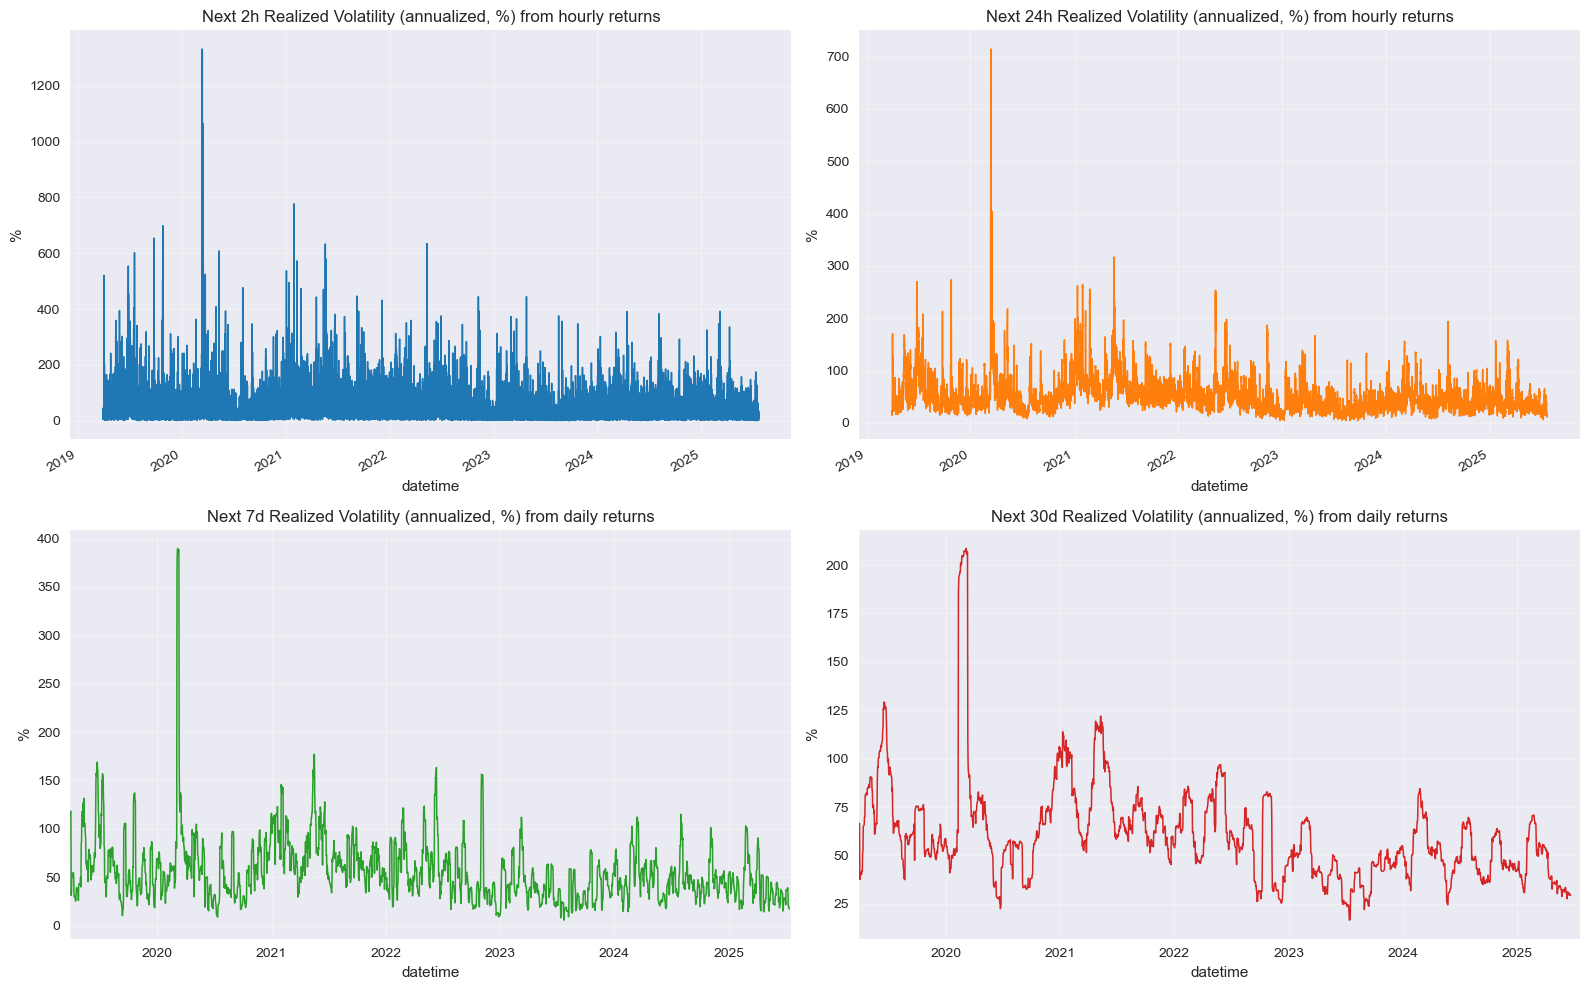

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

# --- Hourly data ---
y_2h  = realized_future_vol(df, h=2,  freq="hourly", percent=True)
y_24h = realized_future_vol(df, h=24, freq="hourly", percent=True)

y_2h.plot(ax=axes[0,0], lw=1.1, color="tab:blue")
axes[0,0].set_title("Next 2h Realized Volatility (annualized, %) from hourly returns")
axes[0,0].set_ylabel("%")

y_24h.plot(ax=axes[0,1], lw=1.1, color="tab:orange")
axes[0,1].set_title("Next 24h Realized Volatility (annualized, %) from hourly returns")
axes[0,1].set_ylabel("%")

# --- Daily data ---
y_7d  = realized_future_vol(df, h=7,  freq="daily", percent=True)
y_30d = realized_future_vol(df, h=30, freq="daily", percent=True)

y_7d.plot(ax=axes[1,0], lw=1.1, color="tab:green")
axes[1,0].set_title("Next 7d Realized Volatility (annualized, %) from daily returns")
axes[1,0].set_ylabel("%")

y_30d.plot(ax=axes[1,1], lw=1.1, color="tab:red")
axes[1,1].set_title("Next 30d Realized Volatility (annualized, %) from daily returns")
axes[1,1].set_ylabel("%")

# Format all subplots
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The plots above illustrate realized volatility at different horizons (2h, 24h, 7d, 30d).  
We can clearly see that:

- **Short horizons (2h, 24h)** are very noisy, with volatility frequently spiking to extreme levels (over 1000% annualized). This reflects the high sensitivity of short-term returns to sudden price moves.  
- **Medium horizons (7d)** smooth out much of the noise, but still capture occasional volatility shocks, especially around major market events.  
- **Long horizons (30d)** are the smoothest series. They reveal persistent volatility regimes (high vs. low volatility periods), and extreme short-term noise is averaged out.

Overall, realized volatility becomes less noisy and more persistent as the horizon increases. Short-term volatility is dominated by noise and jumps, while longer horizons capture structural shifts in the market.


The `close_to_close_vol()` function prepares volatility data from raw spot prices. It resamples the series to daily (or hourly) closes, computes log returns, and then estimates realized volatility using a rolling window. The result is annualized and expressed in percent, producing a clean df with prices, returns, and volatility estimates that can be used directly for forecasting and evaluation.

In [24]:
# Daily 30-day window
daily = close_to_close_vol(df, window=30, freq="daily")
display(daily.tail())

# Hourly 24-hour window
hourly = close_to_close_vol(df, window=24, freq="hourly")
display(hourly.tail())

datetime
2025-07-16 00:00:00+00:00    29.722312
2025-07-17 00:00:00+00:00    28.397649
2025-07-18 00:00:00+00:00    28.855147
2025-07-19 00:00:00+00:00    28.822057
2025-07-20 00:00:00+00:00    28.365997
Freq: D, Name: rv_est_pct, dtype: float64

datetime
2025-07-20 19:00:00+00:00    15.246579
2025-07-20 20:00:00+00:00    14.513043
2025-07-20 21:00:00+00:00    14.602468
2025-07-20 22:00:00+00:00    16.784689
2025-07-20 23:00:00+00:00    17.053145
Freq: h, Name: rv_est_pct, dtype: float64

The idea now is to use past data up to *t* and use it to build a volatility estimator. We will then feed the estimator into a forecast model and then compare against the true observed realized volatility.

While close-to-close returns give us a simple starting point, they are not the most efficient way to measure volatility.  
In fact, much more information is available in the data: daily highs and lows capture the full trading range, and intraday returns (e.g., hourly) provide an even finer picture of realized variance.  

By incorporating these richer sources of information, we can construct **better** volatility estimators. These tend to be less noisy and more accurate than simple close-to-close measures, which should ultimately lead to better forecasts.

### Using the full OHLC Data for Volatility Estimation

Since crypto trades 24/7, we can rely on the full daily range of prices (Open, High, Low, Close) to build more efficient volatility estimators than close-to-close returns alone. Two relevant estimators in this setting are:

- Parkinson Volatility: Uses only the daily high–low range. Under continuous trading (like crypto), this estimator is highly efficient because it captures the full intraday variability without being affected by drift.

- Rogers–Satchell Volatility: Incorporates open, high, low, and close. Unlike Parkinson, it is robust to drift, making it better suited for trending markets such as BTC.

Both are expressed in annualized percent terms and provide a less noisy picture of volatility than simple close-to-close measures.

In [25]:
daily_parkinson = parkinson_vol(df, window=30, freq="daily")
display(daily_parkinson.tail())

hourly_parkinson = parkinson_vol(df, window=24, freq="hourly")
display(hourly_parkinson.tail())

datetime
2025-07-16 00:00:00+00:00    33.958816
2025-07-17 00:00:00+00:00    33.402788
2025-07-18 00:00:00+00:00    33.893990
2025-07-19 00:00:00+00:00    33.864038
2025-07-20 00:00:00+00:00    33.084297
Freq: D, Name: rv_parkinson_pct, dtype: float64

datetime
2025-07-20 19:00:00+00:00    17.558650
2025-07-20 20:00:00+00:00    17.507187
2025-07-20 21:00:00+00:00    16.929794
2025-07-20 22:00:00+00:00    22.666494
2025-07-20 23:00:00+00:00    23.338152
Freq: h, Name: rv_parkinson_pct, dtype: float64

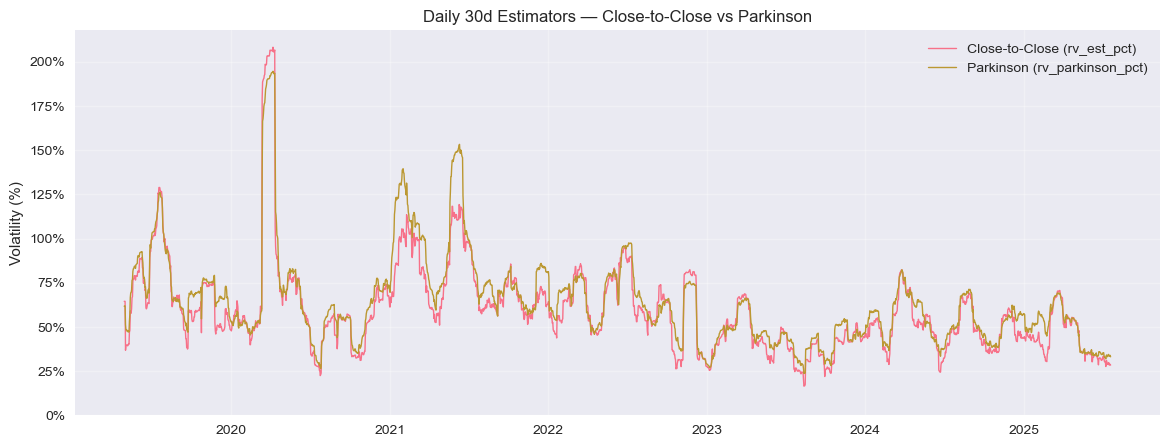

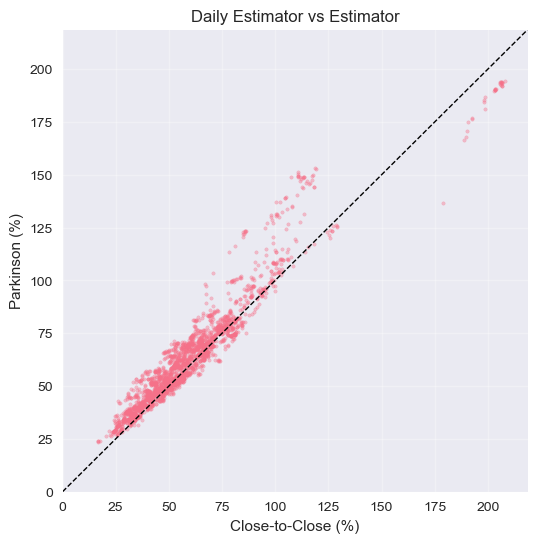

[DAILY] Corr: 0.96 | Mean diff (Park - Close): 4.58 pp | Median ratio: 1.07x


In [26]:
# put the two daily estimators side-by-side
est_daily = pd.concat(
    [daily.rename("rv_est_pct"), daily_parkinson.rename("rv_parkinson_pct")],
    axis=1
).dropna()

# overlay
plt.figure(figsize=(14,5))
plt.plot(est_daily.index, est_daily["rv_est_pct"], label="Close-to-Close (rv_est_pct)", lw=1)
plt.plot(est_daily.index, est_daily["rv_parkinson_pct"], label="Parkinson (rv_parkinson_pct)", lw=1)
plt.title("Daily 30d Estimators — Close-to-Close vs Parkinson")
plt.ylabel("Volatility (%)")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.ylim(bottom=0); plt.grid(alpha=0.3); plt.legend(); plt.show()

# scatter + 45° line
lims = (0, np.nanmax(est_daily.values)*1.05)
plt.figure(figsize=(6,6))
plt.scatter(est_daily["rv_est_pct"], est_daily["rv_parkinson_pct"], s=6, alpha=0.4)
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Close-to-Close (%)"); plt.ylabel("Parkinson (%)")
plt.title("Daily Estimator vs Estimator"); plt.grid(alpha=0.3); plt.show()

# quick stats
corr = est_daily.corr().loc["rv_est_pct", "rv_parkinson_pct"]
diff = est_daily["rv_parkinson_pct"] - est_daily["rv_est_pct"]
ratio = est_daily["rv_parkinson_pct"] / est_daily["rv_est_pct"]
print(f"[DAILY] Corr: {corr:.2f} | Mean diff (Park - Close): {diff.mean():.2f} pp | Median ratio: {ratio.median():.2f}x")


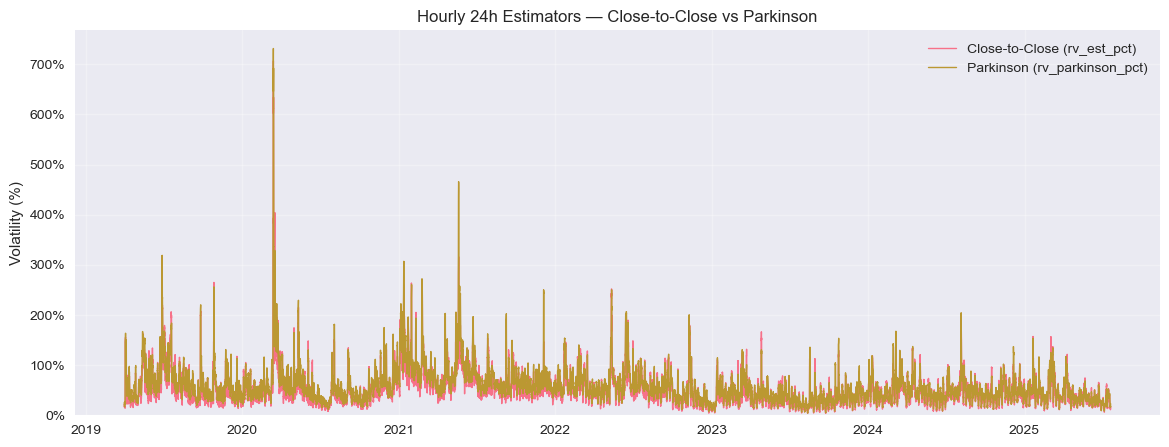

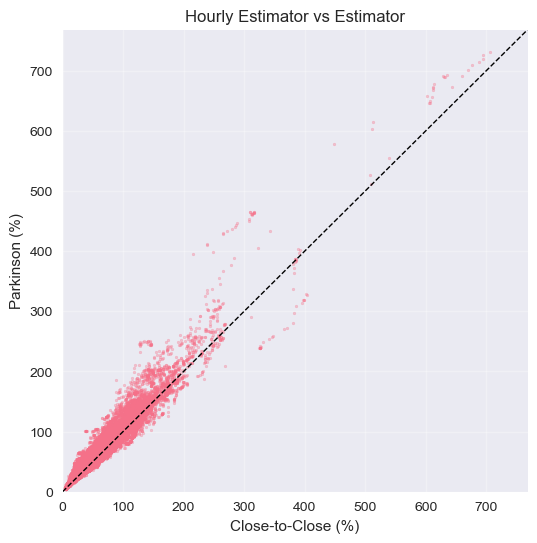

[HOURLY] Corr: 0.96 | Mean diff (Park - Close): 5.99 pp | Median ratio: 1.12x


In [27]:
# side-by-side hourly
est_hourly = pd.concat(
    [hourly.rename("rv_est_pct"), hourly_parkinson.rename("rv_parkinson_pct")],
    axis=1
).dropna()

# overlay
plt.figure(figsize=(14,5))
plt.plot(est_hourly.index, est_hourly["rv_est_pct"], label="Close-to-Close (rv_est_pct)", lw=1)
plt.plot(est_hourly.index, est_hourly["rv_parkinson_pct"], label="Parkinson (rv_parkinson_pct)", lw=1)
plt.title("Hourly 24h Estimators — Close-to-Close vs Parkinson")
plt.ylabel("Volatility (%)")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.ylim(bottom=0); plt.grid(alpha=0.3); plt.legend(); plt.show()

# scatter + 45° line
lims = (0, np.nanmax(est_hourly.values)*1.05)
plt.figure(figsize=(6,6))
plt.scatter(est_hourly["rv_est_pct"], est_hourly["rv_parkinson_pct"], s=4, alpha=0.35)
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Close-to-Close (%)"); plt.ylabel("Parkinson (%)")
plt.title("Hourly Estimator vs Estimator"); plt.grid(alpha=0.3); plt.show()

# quick stats
corr = est_hourly.corr().loc["rv_est_pct", "rv_parkinson_pct"]
diff = est_hourly["rv_parkinson_pct"] - est_hourly["rv_est_pct"]
ratio = est_hourly["rv_parkinson_pct"] / est_hourly["rv_est_pct"]
print(f"[HOURLY] Corr: {corr:.2f} | Mean diff (Park - Close): {diff.mean():.2f} pp | Median ratio: {ratio.median():.2f}x")


NEXT UP: ROGERS-SATCHELL estimator. Then plot the three estimators side-by-side and compare their performance. Then introduce basic forecasting and apply to the estimator.
Question: How should the forecast be outputted?
Evaluate the forecasts with the realized vol.

In [28]:
# ==== DAILY horizon example: h=7 days ====
y_1d   = realized_future_vol(df, h=24, freq="hourly", percent=True)
garch7 = garch_forecast(df, freq="hourly", horizon=24, dist="t")   # Student-t often better for fat tails

cmp = pd.concat([y_7d, garch7, naiveD], axis=1).dropna()

# Quick metrics
rmse_garch = float(np.sqrt(((cmp[garch7.name] - cmp[y_7d.name])**2).mean()))
print(f"[DAILY h=7] RMSE  GARCH: {rmse_garch:.2f}")

# Plot
plt.figure(figsize=(14,5))
plt.plot(cmp.index, cmp[y_7d.name],  label="Realized vol (7d target)", color="black", lw=1.2)
plt.plot(cmp.index, cmp[garch7.name], label="GARCH forecast (7d)",    color="tab:blue", lw=1.1, alpha=0.9)
plt.title("7-Day Volatility: GARCH vs Naive vs Realized")
plt.ylabel("Annualized Volatility (%)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


NameError: name 'naiveD' is not defined

### Testing the simple forecasts (Naive & EWMA)

We now test two simple volatility forecasts: **Naive** and **EWMA (RiskMetrics)**. The Naive model is the simplest possible approach, while EWMA adds exponential weighting so that recent returns matter more than older ones. By comparing these forecasts against realized volatility at horizons such as 1, 5, 10, and 30 days, we get a natural baseline that more complex models (e.g., GARCH) should aim to beat.

All series are **annualized and expressed in %** and are **properly aligned** (forecasts at time *t* use only information up to *t* and are compared to realized volatility over t+1,...,t+h).

**Outputs**
- **Naive forecast:** `naive_h{h}_pct`  
- **EWMA forecast:** `ewma_naive_h1` for 1-day, and `ewma_forecast_h{h}` for h > 1  
- **Realized target:** `realized_h{h}_pct` (volatility that actually occurred over the next h days)

**Evaluation metrics**
- **MAE** → mean absolute error (average size of errors)  
- **RMSE** → root mean squared error (penalizes large errors more)  
- **Bias** → mean error (shows if the model systematically over- or under-forecasts)


In [ ]:
horizons = [1, 2, 10, 30]

daily_df['ewma_vol'] = ewma_vol(daily_df['log_returns'], lam=0.94, ann=365)

# --- build forecasts & realized targets ---
for h in horizons:
    # naive forecast
    daily_df[f'naive_h{h}_pct'] = naive_forecast(daily_df['rv_est_pct'], h=h)
    
    # ewma forecast
    if h == 1:
        daily_df[f'ewma_h{h}_pct'] = daily_df['ewma_vol'].shift(1)
    else:
        daily_df[f'ewma_h{h}_pct'] = daily_df['ewma_vol'].shift(1) * np.sqrt(h)
    
    # realized future volatility target (now correct)
    daily_df[f'realized_h{h}_pct'] = realized_future_vol(daily_df['log_returns'], h=h, ann=365)

# --- evaluation ---

results = {}

for h in horizons:
    # realized
    t = daily_df[f'realized_h{h}_pct']
    
    for model in ['naive', 'ewma']:
        f = daily_df[f'{model}_h{h}_pct']
        df_eval = pd.concat([f, t], axis=1).dropna()
        err = df_eval[f'{model}_h{h}_pct'] - df_eval[f'realized_h{h}_pct']
        
        results[(model, h)] = {
            "MAE": err.abs().mean(),
            "RMSE": np.sqrt((err**2).mean()),
            "Bias": err.mean()
        }

results_df = pd.DataFrame(results).T.round(2)
print(results_df)

NameError: name 'ewma_vol' is not defined

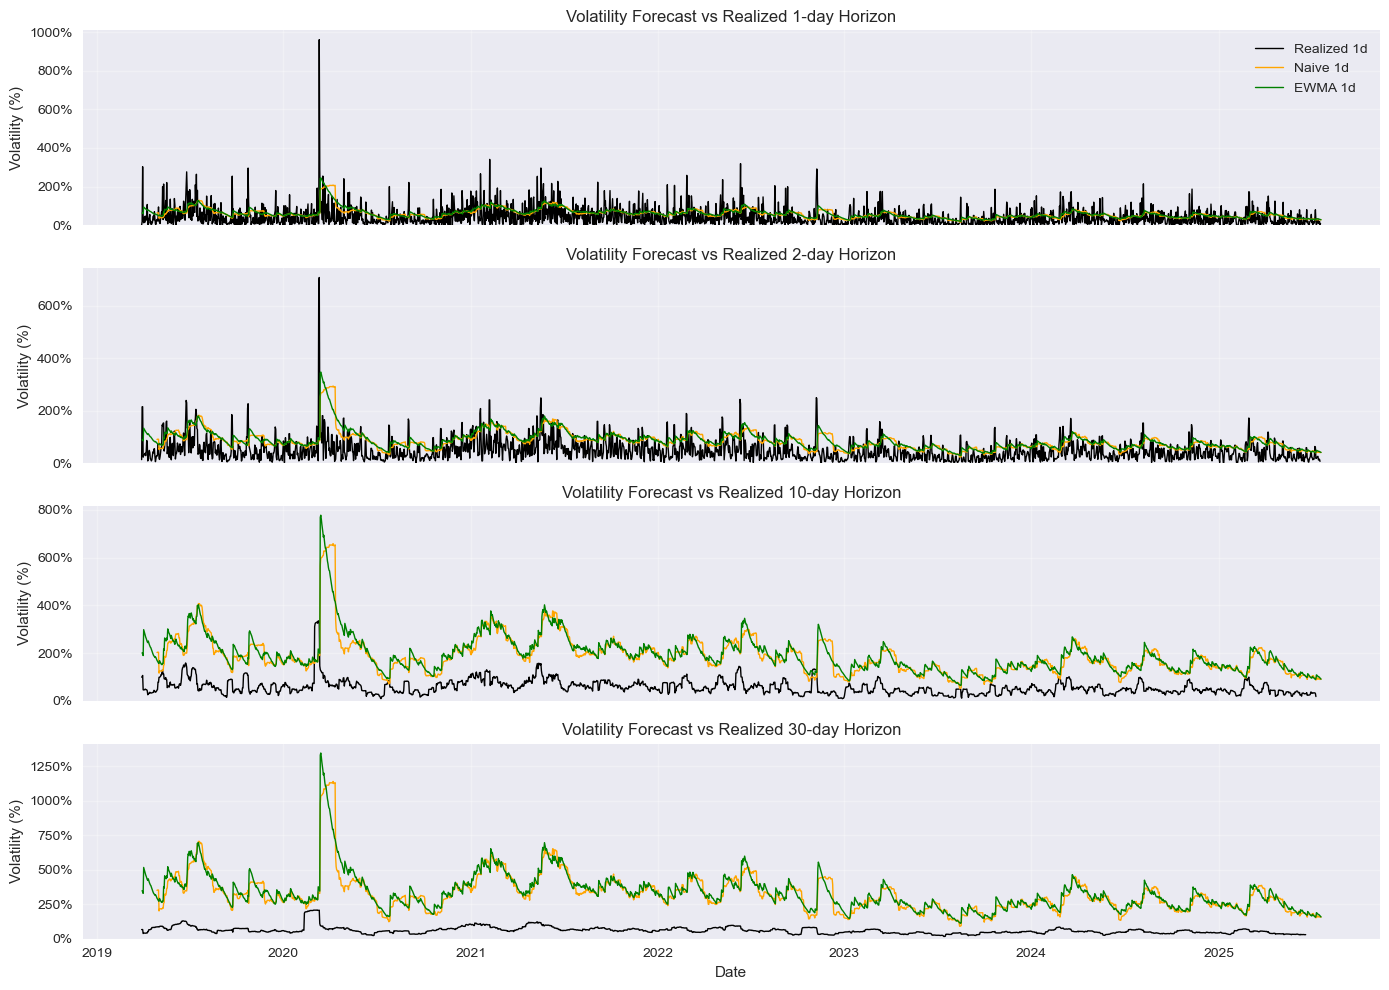

In [ ]:
fig, axes = plt.subplots(len(horizons), 1, figsize=(14, 10), sharex=True)

for i, h in enumerate(horizons):
    ax = axes[i]

    realized_col = f"realized_h{h}_pct"
    naive_col    = f"naive_h{h}_pct"
    ewma_col     = f"ewma_h{h}_pct"

    if realized_col in daily_df:
        ax.plot(daily_df.index, daily_df[realized_col], label=f"Realized {h}d", color="black", lw=1)
    if naive_col in daily_df:
        ax.plot(daily_df.index, daily_df[naive_col], label=f"Naive {h}d", color="orange", lw=1)
    if ewma_col in daily_df:
        ax.plot(daily_df.index, daily_df[ewma_col], label=f"EWMA {h}d", color="green", lw=1)

    ax.set_title(f"Volatility Forecast vs Realized {h}-day Horizon")
    ax.set_ylabel("Volatility (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()


We observe that choosing a very short horizon such as 1 or 2 days leads to forecasts that track realized volatility fairly well, but the underlying rolling volatility estimate over such a short window is extremely noisy. This noise makes the forecast unstable and difficult to interpret in practice. On the other hand, when we extend the horizon to longer periods such as 10 or 30 days, the realized volatility measure becomes much smoother and more stable, but the Naive forecast is less accurate because recent short-term changes in volatility are averaged out and not captured quickly enough.
This highlights the classic trade-off in volatility modeling: short horizons give forecasts that are responsive but noisy, while long horizons give forecasts that are stable but sluggish.

Our current forecasts (Naive, EWMA) are **not sufficient**.
They either react too much to noise (short horizons) or are too sluggish (long horizons). Overall, forecast accuracy remains poor.

To improve, we need to go **beyond simple log returns**—incorporating richer data (intraday variation, option-implied measures, market microstructure signals) and exploring more advanced models.

**Bottom line:** better methods, more data.
